In [207]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, beta, expon
from scipy.optimize import root, minimize

SEED = 42
rng = np.random.default_rng(SEED)  # results are reproducible

# **Quantitative Credit Risk Modelling in Python**

**Author:** Simone Audisio

This notebook implements the main building blocks of credit risk measurement, from the Basel IRB capital formula to counterparty credit risk, using Monte Carlo simulation and numerical calibration. Notation and benchmark examples follow chapter 3 (*Credit Risk*) of Roncalli, *Handbook of Financial Risk Management* (CRC Press, 2020).

**Contents**

1. **Basel IRB model**: Vasicek one-factor model, loss quantile as a function of α, PD, LGD and ρ
2. **LGD estimation**: Beta calibration (method of moments vs maximum likelihood) and Monte Carlo VaR under different LGD assumptions
3. **Default probability**: Merton structural model, CIR intensity model and CDS pricing, hazard-rate estimation (exponential, Gompertz, piecewise exponential) and hazard rates from a rating migration matrix
4. **Default correlation**: Gaussian one-factor copula, loss distribution, VaR and Expected Shortfall
5. **Counterparty credit risk**: exposure profile, expected exposure, PFE and CVA of a call option position

**Main tools:** `numpy`, `pandas`, `scipy` (`optimize`, `stats`), `matplotlib`. Random numbers are seeded for reproducibility.

# **Basel IRB model**

## Loss quantile as a function of the confidence level

Reproduce the Figure 3.21 in Roncalli’s book, plotting the quantile function F−1(α) when α changes. 

Consider a portfolio of 100 credits, each with EAD=1$ mln, 50% expected LGD and 5% individual default probability.

In [208]:
# Parameters
EAD = 1e6  # $1 million per credit
n_credits = 100
LGD = 0.5
p_i = 0.05
rho_values = [0.1, 0.3]

eps = 1e-3  # keeps parameters away from 0 and 1, where the quantile function diverges
alpha = np.linspace(0 + eps, 1 - eps, 1000)  # Confidence levels

The IRB approach takes as credit risk measure the sum of the individual risk contributions. Hence, the overall exposure to credit risk is:

\begin{equation*}
\text{VaR} = \sum_{i=1}^n RC_i = \sum_{i=1}^n \omega_i \cdot E[LGD_i] \cdot p_i(x)
\end{equation*}

where $p_i(x)$ is the default probability conditional on the systematic factor being at its worst-case value for confidence level $\alpha$. The model relies on the following assumptions:

- LGD is independent of the default times
- Default times $\tau_i$ depend on a single risk factor and are conditionally independent
- The portfolio is infinitely fine-grained (no concentration risk)

The only missing piece is the conditional default probability, which is modelled with Merton's one-factor model (Vasicek). Conditional on the systematic factor $X = x$:

\begin{equation*}
p_i (x) = \Phi\left(\frac{\Phi^{-1}(p_i) - \sqrt{\rho}\, x}{\sqrt{1-\rho}}\right)
\end{equation*}

The worst case at confidence level $\alpha$ is $x = \Phi^{-1}(1-\alpha) = -\Phi^{-1}(\alpha)$, which gives the loss quantile implemented below:

\begin{equation*}
F^{-1}(\alpha) = EAD \cdot LGD \cdot \Phi\left(\frac{\Phi^{-1}(p_i) + \sqrt{\rho}\, \Phi^{-1}(\alpha)}{\sqrt{1-\rho}}\right)
\end{equation*}

In [209]:
# VaR in the IRB formula (loss quantile per credit)

def vasicek_quantile(alpha, p_i, rho, EAD, LGD):
    phi = norm.cdf((norm.ppf(p_i) + np.sqrt(rho) * norm.ppf(alpha)) / np.sqrt(1 - rho))
    return EAD * LGD * phi

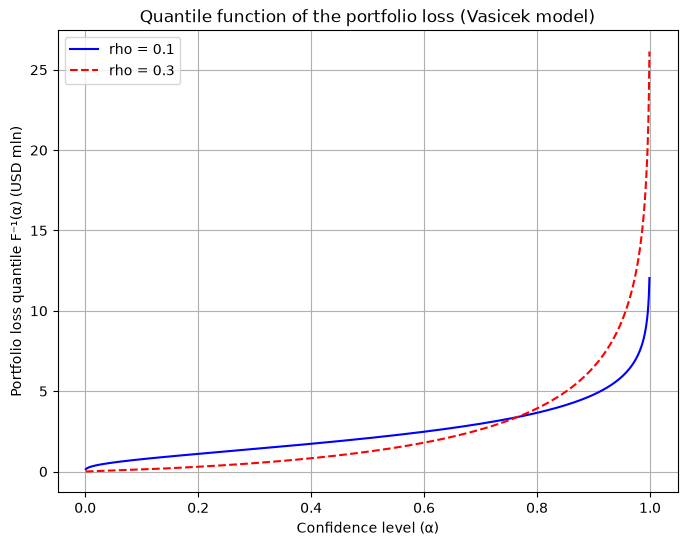

In [210]:
# Plot
colors = ['b', 'r']
linestyle = ['-', '--']

plt.figure(figsize=(8, 6))
for rho_i, c, ls in zip(rho_values, colors, linestyle):
    # loss of the whole portfolio in $ mln
    portfolio_loss = n_credits * vasicek_quantile(alpha, p_i, rho_i, EAD, LGD) / 1e6
    plt.plot(alpha, portfolio_loss, label=f'rho = {rho_i}', color=c, linestyle=ls)

plt.xlabel('Confidence level (α)')
plt.ylabel('Portfolio loss quantile F⁻¹(α) (USD mln)')
plt.title('Quantile function of the portfolio loss (Vasicek model)')
plt.legend()
plt.grid(True)
plt.show()

## Sensitivity to PD, LGD, ρ and α

In [211]:
EAD = 100
LGD = 0.7
rho = 0.2
alpha = 0.9
p_i = np.linspace(0+eps,1-eps,1000)

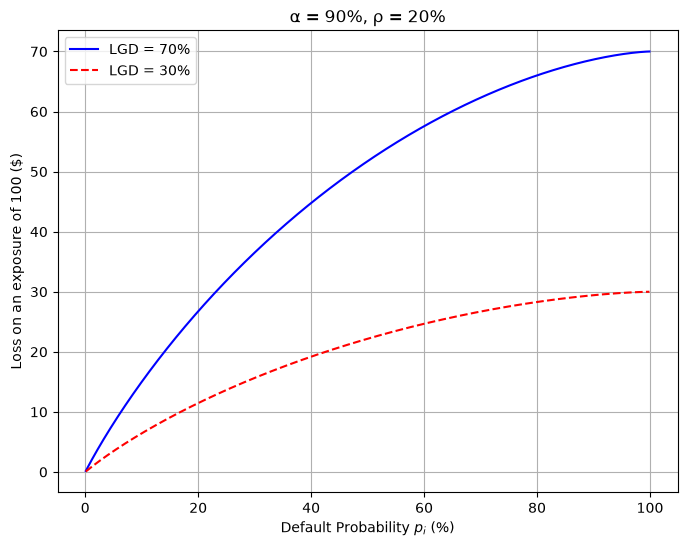

In [212]:
EAD = 100
LGD = [0.7,0.3]
rho = 0.2
alpha = 0.9
p_i = np.linspace(0+eps,1-eps,1000)

plt.figure(figsize=(8, 6))
plt.plot(p_i * 100, vasicek_quantile(alpha=0.90, p_i=p_i, rho=rho, EAD=EAD, LGD=LGD[0]), label='LGD = 70%', color=colors[0], linestyle=linestyle[0])
plt.plot(p_i * 100, vasicek_quantile(alpha=0.90, p_i=p_i, rho=rho, EAD=EAD, LGD=LGD[1]), label='LGD = 30%', color=colors[1], linestyle=linestyle[1])
plt.xlabel('Default Probability $p_i$ (%)')
plt.ylabel('Loss on an exposure of 100 ($)')
plt.title('α = 90%, ρ = 20%')
plt.legend()
plt.grid(True)
plt.show()

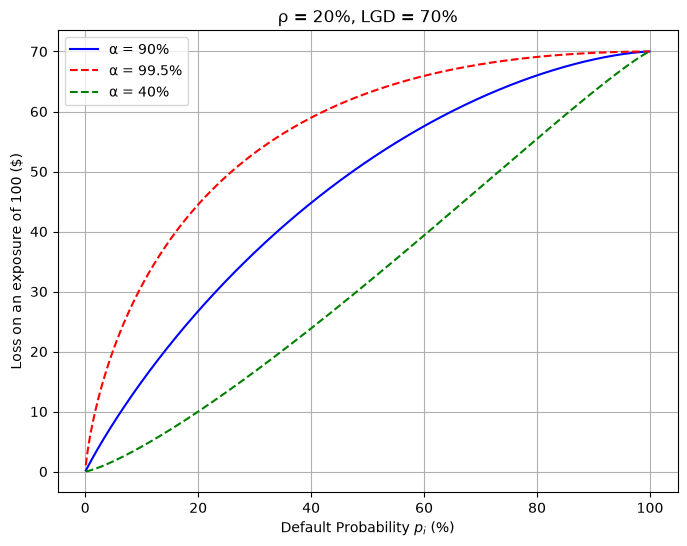

In [213]:
EAD = 100
LGD = 0.7
rho = 0.2
alpha = [0.9, 0.995, 0.4]
p_i = np.linspace(0+eps,1-eps,1000)

colors = ['b', 'r', 'g']
linestyle = ['-','--']

plt.figure(figsize=(8, 6))
plt.plot(p_i * 100, vasicek_quantile(alpha= alpha[0], p_i=p_i, rho=rho, EAD=EAD, LGD=LGD), label='α = 90%' , color=colors[0], linestyle=linestyle[0])
plt.plot(p_i * 100, vasicek_quantile(alpha= alpha[1], p_i=p_i, rho=rho, EAD=EAD, LGD=LGD), label='α = 99.5%', color=colors[1], linestyle=linestyle[1])
plt.plot(p_i * 100, vasicek_quantile(alpha= alpha[2], p_i=p_i, rho=rho, EAD=EAD, LGD=LGD), label='α = 40%', color=colors[2], linestyle=linestyle[1])
plt.xlabel('Default Probability $p_i$ (%)')
plt.ylabel('Loss on an exposure of 100 ($)')
plt.title('ρ = 20%, LGD = 70%')
plt.legend()
plt.grid(True)
plt.show()

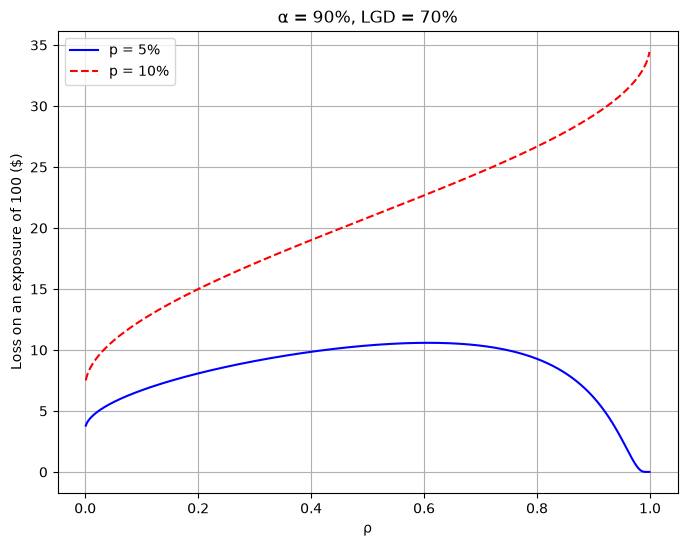

In [214]:
EAD = 100
LGD = 0.7
rho = np.linspace(0 + eps, 1 - eps, 1000)
alpha = 0.9
p_i = [0.05, 0.10]

colors = ['b', 'r']
linestyle = ['-', '--']

plt.figure(figsize=(8, 6))
for p, c, ls in zip(p_i, colors, linestyle):
    plt.plot(rho, vasicek_quantile(alpha=alpha, p_i=p, rho=rho, EAD=EAD, LGD=LGD),
             label=f'p = {p:.0%}', color=c, linestyle=ls)
plt.xlabel('ρ')
plt.ylabel('Loss on an exposure of 100 ($)')
plt.title('α = 90%, LGD = 70%')
plt.legend()
plt.grid(True)
plt.show()

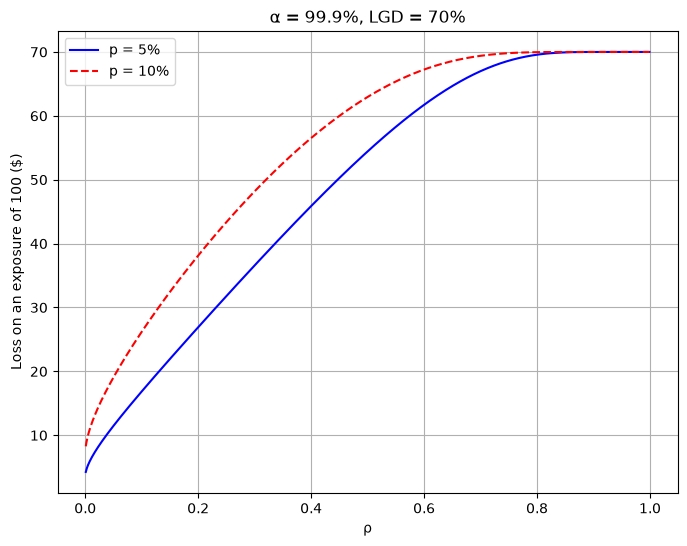

In [215]:
EAD = 100
LGD = 0.7
rho = np.linspace(0 + eps, 1 - eps, 1000)
alpha = 0.999
p_i = [0.05, 0.10]

colors = ['b', 'r']
linestyle = ['-', '--']

plt.figure(figsize=(8, 6))
for p, c, ls in zip(p_i, colors, linestyle):
    plt.plot(rho, vasicek_quantile(alpha=alpha, p_i=p, rho=rho, EAD=EAD, LGD=LGD),
             label=f'p = {p:.0%}', color=c, linestyle=ls)
plt.xlabel('ρ')
plt.ylabel('Loss on an exposure of 100 ($)')
plt.title('α = 99.9%, LGD = 70%')
plt.legend()
plt.grid(True)
plt.show()

# **LGD estimation**

From the previous exercise we know that the IRB model requires four parameters:

1. Effective maturity
2. Exposure at Default (EAD)
3. Loss Given Default (LGD)
4. Probability of Default (PD)

With the only exception of the first one, which is clearly defined, all these parameters should be estimated/modelled. In this exercise we will see several ways to model the Loss Given Default.

The **LGD** is what remains of an active position, given that it has defaulted. It can be defined as:

\begin{equation*}
LGD = 1 - R + c
\end{equation*}

with **R** as the recovery rate and **c** as the litigation costs. According to the way in which we choose to proceed it is possible to consider LGD as a random variable and then estimate its distribution $\mathcal{F}(x)$ or consider only $E[LGD | X_1 = x_1 , \dots , X_n = x_n] $ as in the IRB model. With this aim, stochastic modelling and economic modelling are the most common approaches; we will focus on the first one.

The most widespread choice for the distribution of the LGD is the Beta distribution:


\begin{equation*}
f(x) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{\mathcal{B}(\alpha,\beta)}
\end{equation*}

where $\mathcal{B}(\alpha,\beta) = \int_0^1 t^{\alpha-1}(1-t)^{\beta-1} dt $. In the first exercise we will see how it can be estimated.

## Calibrating a Beta distribution to observed LGDs

Consider the following set of observed losses given default for a sample of homogeneous defaulted credits: 

$68\%,90\%,22\%,45\%,17\%,25\%,89\%,65\%, 75\%,56\%,87\%,92\%,46\%$.

Fit a Beta distribution to this sample, using the method of moments and maximum likelihood.

Report the estimated parameters and plot the associated pdf in the two cases

In [216]:
# Observed LGDs of a sample of homogeneous defaulted credits

LGD = np.array([0.68, 0.9, 0.22, 0.45, 0.17, 0.25, 0.89, 0.65, 0.75, 0.56, 0.87, 0.92, 0.46])

### *Method of moments*

With the method of moments we will try to match the first two moments to the sample ones. We will need to estimate $\hat \mu$ and $\hat \sigma^2$ from the sample and then we will find $\hat \alpha$ and $\hat \beta$ by solving the following system:

\begin{cases}
\hat \alpha = \frac{\hat \mu^2 (1-\hat \mu)}{\hat \sigma^2} - \hat \mu \\
\hat \beta = \frac{\hat \mu (1-\hat \mu)^2}{\hat \sigma^2} - (1 - \hat \mu)
\end{cases}

In [217]:
sample_mu = LGD.mean()
sample_var = LGD.var(ddof = 1) #set ddof to use sample variance

print(f"The sample mean is {sample_mu:.4f}")
print(f"The sample variance is {sample_var:.4f}")

The sample mean is 0.5977
The sample variance is 0.0730


In [218]:
alpha_mm = (((sample_mu**2) * (1-sample_mu)) / sample_var) - sample_mu
beta_mm = (((sample_mu) * (1-sample_mu)**2) / sample_var) - (1- sample_mu)

print(f"The estimated alpha is {alpha_mm:.4f}")
print(f"The estimated beta is {beta_mm:.4f}")

The estimated alpha is 1.3705
The estimated beta is 0.9225


### *Maximum likelihood*

With the maximum likelihood we choose the parameters that maximize the likelihood function which measures the probability of observing the given data.

In [219]:
alpha_mle, beta_mle, loc, scale = beta.fit(LGD, floc=0, fscale=1)

print(f"The estimated alpha is {alpha_mle:.4f}")
print(f"The estimated beta is {beta_mle:.4f}")

The estimated alpha is 1.8356
The estimated beta is 1.2478


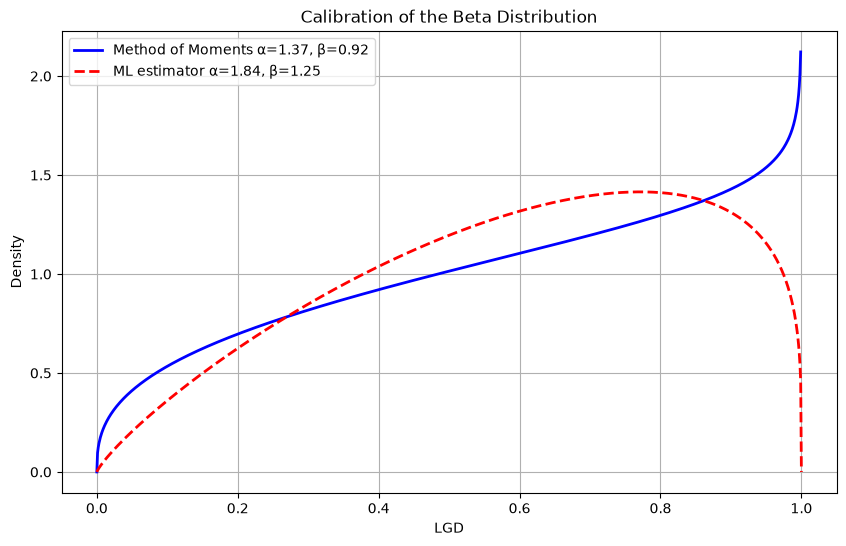

In [220]:
x = np.linspace(0, 1, 1000)
pdf_mle = beta.pdf(x, alpha_mle, beta_mle)
pdf_mm = beta.pdf(x, alpha_mm, beta_mm)

colors = ['b', 'r']
linestyle = ['-','--']

plt.figure(figsize=(10, 6))
plt.plot(x, pdf_mm, lw=2, label=f'Method of Moments α={alpha_mm:.2f}, β={beta_mm:.2f}', color = colors[0])
plt.plot(x, pdf_mle, lw=2, label=f'ML estimator α={alpha_mle:.2f}, β={beta_mle:.2f}', color = colors[1], linestyle = linestyle[1])
plt.title('Calibration of the Beta Distribution')
plt.xlabel('LGD')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

## Empirical LGD distribution, fitted Beta and Monte Carlo VaR

Consider the empirical distribution of LGDs of Example 35 in Roncalli’s book.

### - Plot the empirical distribution of LGDs and the fitted Beta distribution

In [221]:
# Empirical LGD distribution (Roncalli, Example 35): support and number of observations

LGD = np.array([0, 10, 20, 25, 30, 40, 50, 60, 70, 75, 80, 90, 100]) / 100
p = np.array([1, 2, 10, 25, 10, 2, 0, 2, 10, 25, 10, 2, 1])
sample = np.repeat(LGD, p)

In [222]:
mu  = sample.mean()
var = sample.var(ddof=1)
alpha_mm = (mu**2 * (1-mu) / var) - mu
beta_mm  = (mu * (1-mu)**2 / var) - (1-mu)

In [223]:
# Theoretical PDF
x = np.linspace(0, 1, 500)
pdf_mm = beta.pdf(x, alpha_mm, beta_mm)

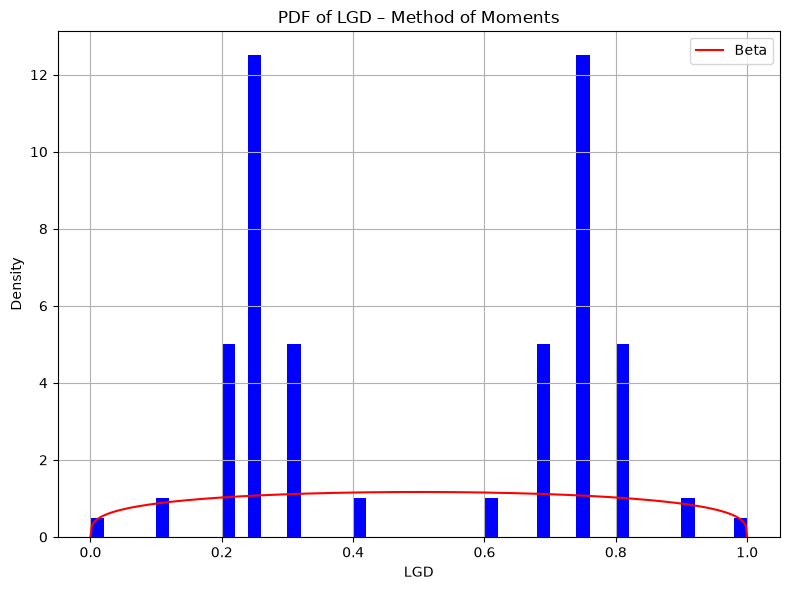

In [224]:
# Plot

plt.figure(figsize=(8, 6))
plt.hist(sample, bins=50, density=True,weights=np.ones_like(sample)/sample.size, color='blue')
plt.plot(x, pdf_mm, 'r', label=f'Beta')
plt.xlabel('LGD')
plt.ylabel('Density')
plt.title('PDF of LGD – Method of Moments')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

A single Beta distribution is unimodal (here almost flat), so it cannot reproduce the bimodal shape of the empirical LGD distribution: the method of moments only matches the first two moments (mean and variance). This matters when the tails of the loss distribution are driven by the LGD, as in the Monte Carlo exercise below.

### - Consider a portfolio of 10 loans, whose loss is equal to:

\begin{equation*}
L = \sum^{10}_{i=1} EAD_i \cdot LGD_i \cdot 1_{\{\tau_i \leq T_i\}}
\end{equation*}

with $EAD_i = 1000\$$, $T_i = 5$ years for each $i$, and default time $\tau_i$ exponentially distributed with intensity parameter $\lambda_i$ as in Example 36 in Roncalli's book.

Applying Monte Carlo simulation, generate $N = 10^6$ scenarios, determine the distribution of losses, plot it and compute the VaR at the 99%, 99.5% and 99.9% levels when the LGDs are modelled according to:
- the empirical distribution
- the calibrated Beta distribution
- the expected value $E[LGD_i] = 50\%$ (granular portfolio hypothesis)

LGDs are drawn independently for each loan and each scenario.

In [225]:
# Empirical LGD distribution (Roncalli, Example 35): support and probabilities
LGD = np.array([0, 0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1])
w_lgd = np.array([0.01, 0.02, 0.1, 0.25, 0.1, 0.02, 0, 0.02, 0.1, 0.25, 0.1, 0.02, 0.01])
assert np.isclose(w_lgd.sum(), 1) and np.isclose((LGD * w_lgd).sum(), 0.5)  # E[LGD] = 50%

In [226]:
n_loans = 10  # 10 loans
EAD = 1000
T = 5

# default time tau is exponentially distributed, intensities in bps
lam_i = np.array([10, 10, 25, 25, 50, 100, 250, 500, 500, 1000])
lam_i_decimal = lam_i / 10000

In [227]:
N = 10**6

# Beta distribution calibrated in the previous exercise
# (method of moments on the empirical LGD distribution)
alpha_cal, beta_cal = alpha_mm, beta_mm
print(f"Calibrated Beta parameters: alpha = {alpha_cal:.4f}, beta = {beta_cal:.4f}")

Calibrated Beta parameters: alpha = 1.2922, beta = 1.2922


In [228]:
def simulated_loss(lgd_model, n_scenarios, rng):
    """Portfolio loss over [0, T] for 10 loans with independent exponential default times.
    LGDs are drawn independently for each loan and each scenario."""
    total_loss = np.zeros(n_scenarios)
    for i in range(n_loans):
        # the loan defaults within T if tau_i <= T
        default = rng.exponential(scale=1 / lam_i_decimal[i], size=n_scenarios) <= T
        if lgd_model == 'empirical':
            lgd = rng.choice(LGD, size=n_scenarios, p=w_lgd)
        elif lgd_model == 'fitted':
            lgd = beta.rvs(alpha_cal, beta_cal, size=n_scenarios, random_state=rng)
        else:  # 'granular': LGD replaced by its expected value
            lgd = 0.5
        total_loss += EAD * lgd * default
    return total_loss

In [229]:
losses_empirical = simulated_loss('empirical', N, rng)
losses_fitted = simulated_loss('fitted', N, rng)
losses_granular = simulated_loss('granular', N, rng)

In [230]:
var_levels = [99, 99.5, 99.9]

var_table = pd.DataFrame({
    'Empirical LGD': np.percentile(losses_empirical, var_levels),
    'Beta LGD': np.percentile(losses_fitted, var_levels),
    'Granular (E[LGD] = 50%)': np.percentile(losses_granular, var_levels),
}, index=[f'VaR {l}%' for l in var_levels])

var_table.round(0)

,Empirical LGD,Beta LGD,Granular (E[LGD] = 50%)
VaR 99%,2050.0,2046.0,1500.0
VaR 99.5%,2250.0,2259.0,2000.0
VaR 99.9%,2600.0,2650.0,2000.0


The empirical and the Beta LGD models give very similar VaR. Replacing the LGD with its expected value (granular hypothesis) produces a clearly lower VaR, because it ignores LGD uncertainty: with only 10 loans the portfolio is far from fine-grained, so LGD variability adds to tail risk.

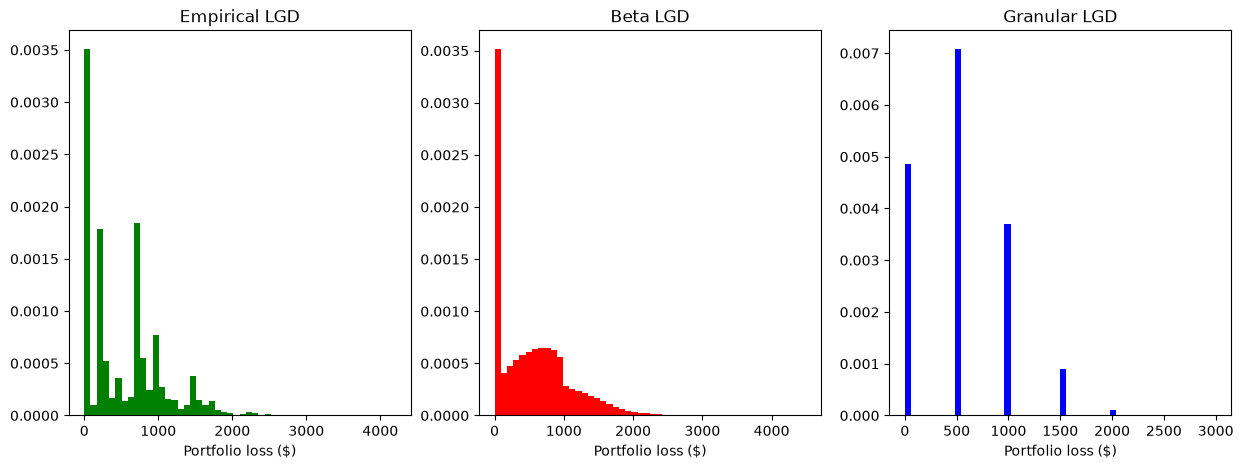

In [231]:
plt.figure(figsize=(15, 5))
plt.subplot(1,3,1)
plt.hist(losses_empirical, bins=50, density=True, color = 'g')
plt.title('Empirical LGD')
plt.xlabel('Portfolio loss ($)')
plt.subplot(1,3,2)
plt.hist(losses_fitted, bins=50, density=True, color = 'r')
plt.title('Beta LGD')
plt.xlabel('Portfolio loss ($)')
plt.subplot(1,3,3)
plt.hist(losses_granular, bins=50, density=True, color = 'b')
plt.title('Granular LGD')
plt.xlabel('Portfolio loss ($)')
plt.show()

# **Default Probability**

## Merton structural model

In a market where the risk-free rate is r = 2.5%, consider a firm with the following characteristics:
- Current equity value: 15500
- Average maturity of debt: 1 year
- Face value of debt: 40000
- Equity volatility: 18%

Compute the market value of debt D(0), the 1-year term spread, the endogenous recovery
and the volatility of firm value consistent with these values in Merton’s model.

In [232]:
# Given Data
t = 0
r = 0.025 #rf rate
S0 = 15500 #equity value
T = 1 #maturity
FV = 40000 #face value of debt
sigma_s = 0.18


According to Merton's model, the total value of the firm is the sum of debt and equity:

\begin{equation*}
V(t) = D(t) + S(t)
\end{equation*}

where $D(t)$ is the debt value and $S(t)$ is the equity value, and the firm value follows:

\begin{equation*}
dV(t) = \mu V(t) dt + \sigma_V V(t) dW_t
\end{equation*}

Given that the payoff of equity at maturity is $S(T) = \max(0, V(T) - F)$, equity can be seen as a call option on the firm's assets with strike $F$. It follows that:

\begin{equation*}
S(t) = BS_C(\cdot)
\end{equation*}

In [233]:
def BS_pricing(option_type, t, T, K, r, sigma, S0):

    #use only "call" or "put"

    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * (T - t)) / (sigma * np.sqrt(T - t))
    
    d2 = d1 - sigma * np.sqrt(T - t)

    if option_type == "call":
        c = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        return d1,d2,c
    elif option_type == "put":
        p = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
        return d1,d2,p
    else:
        return "Please use only 'call' or 'put'"

At the same time, for the bond at maturity 
it holds that:

\begin{equation*}
\bar P(t,T) = Fe^{-r(T-t)} \Phi(d_2) + V(t) \Phi(-d1)
\end{equation*}

which can also be obtained using the put-call parity: 

\begin{equation*}
\bar P(t,T) = Fe^{-r(T-t)} - BS_p(t,T,F,r,\sigma,V(T))
\end{equation*}

In [234]:
def merton_model(x):

    V0, sigma_V = x

    d1 = (np.log(V0 / FV) + (r + 0.5 * sigma_V**2) * T) / (sigma_V * np.sqrt(T))
    d2 = d1 - sigma_V * np.sqrt(T)


    eq1 = V0 * norm.cdf(d1) - FV * np.exp(-r * T) * norm.cdf(d2) - S0
    eq2 = norm.cdf(d1) * sigma_V * V0 - sigma_s * S0

    return [eq1, eq2]


Finally, through Itô's formula, we obtain the following system. 

\begin{cases}
S0 = V(0) \Phi(d_1)- F e^{-rT} \Phi(d_2) \\
\sigma_s S0 = \Phi(d_1) \sigma_V V(0)
\end{cases}

The problem is that we still need V(0) and $\sigma_v$, that are unobservable. We solve the system numerically.

In [235]:
initial_guess = [40000, 0.3]
sol = root(merton_model, initial_guess)

V0 = sol.x[0]
sigma_V = sol.x[1]

In [236]:
d1,d2,BS_p = BS_pricing(option_type = "put", t = t, T = T, K = FV, r = r, sigma = sigma_V, S0 = V0)

The formula for the spread is:

\begin{equation*}
s(0,T) = - \frac{1}{T} ln \left( \frac{\bar P(0,T)}{Fe^{-rT}}\right)
\end{equation*}

In [237]:
D0 = FV * np.exp(-r * (T - t)) - BS_p

# Consistency check: D(0) = V(0) - S(0)
assert np.isclose(D0, V0 - S0, rtol=1e-6)

spread = - (1 / T) * np.log(D0 / (FV * np.exp(-r * T)))
recovery_rate = V0 / FV * np.exp(r * T) * norm.cdf(-d1) / norm.cdf(-d2)

In [238]:
print(f"Firm value V(0) = {V0:,.2f}, asset volatility sigma_V = {sigma_V:.2%}")
print(f"The market value of debt D(0) is {D0:,.2f}")
print(f"The one-year term spread is {spread * 1e4:.4f} bps")
print(f"The endogenous recovery rate is {recovery_rate:.2%}")

Firm value V(0) = 54,512.40, asset volatility sigma_V = 5.12%
The market value of debt D(0) is 39,012.40
The one-year term spread is 0.0000 bps
The endogenous recovery rate is 99.25%


With these inputs the firm is very far from default: the implied asset value is about 1.36 times the face value of debt and the implied asset volatility is only about 5%. The probability of ending below the debt threshold is therefore negligible, which is why the term spread is essentially zero and the endogenous recovery rate is close to 100%.

## Intensity-based model (CIR) and CDS pricing

Consider an intensity-based model in which the intensity is stochastic and follows a CIR-like
process with parameters k = 0.3,θ = 0.15,σ = 0.2.
- Compute and plot the survival probability.
- Compute the fair premium of a CDS where payments in the premium leg are annual and which offers 5-year protection on the firm characterised by the above survival probabiliities, assuming LGD = 5 million and a constant interest rate r = 3.5%

In [239]:
# CIR-like intensity parameters
k = 0.3
theta = 0.15
sigma = 0.2

The CIR-intensity model has the following formula:

$$
S(t,T) = A(t,T) \cdot \exp\left( -B(t,T) \cdot \lambda_t \right)
$$

where:

- $h = \sqrt{k^2 + 2\sigma^2}$
- $B(t,T) = \dfrac{2\left( e^{h(T - t)} - 1 \right)}{2h + (k + h)\left( e^{h(T - t)} - 1 \right)}$
- $A(t,T) = \left( \dfrac{2h \cdot e^{(k + h)(T - t)/2}}{2h + (k + h)\left( e^{h(T - t)} - 1 \right)} \right)^{\frac{2k\theta}{\sigma^2}}$

In [240]:
def CIR_intensity_process(k,theta,sigma,lamda,t,T):

    h = np.sqrt(k**2 + 2*sigma**2)

    alpha = ( 2*h*np.exp((k+h)*(T-t) / 2) / (2*h + (k+h) * (np.exp((T-t)*h)-1)))**(2*k*theta/sigma**2)

    beta = (2* (np.exp((T-t)*h)-1)) / (2*h + (k+h) * (np.exp((T-t)*h)-1))

    survival = alpha*np.exp(-beta*lamda)

    return survival

In [241]:
T_grid = np.linspace(0, 10, 100)
t = 0
l = 0.25  # initial intensity above the long-run level theta (riskier than the long-run average)

S = CIR_intensity_process(k, theta, sigma, l, t, T_grid)

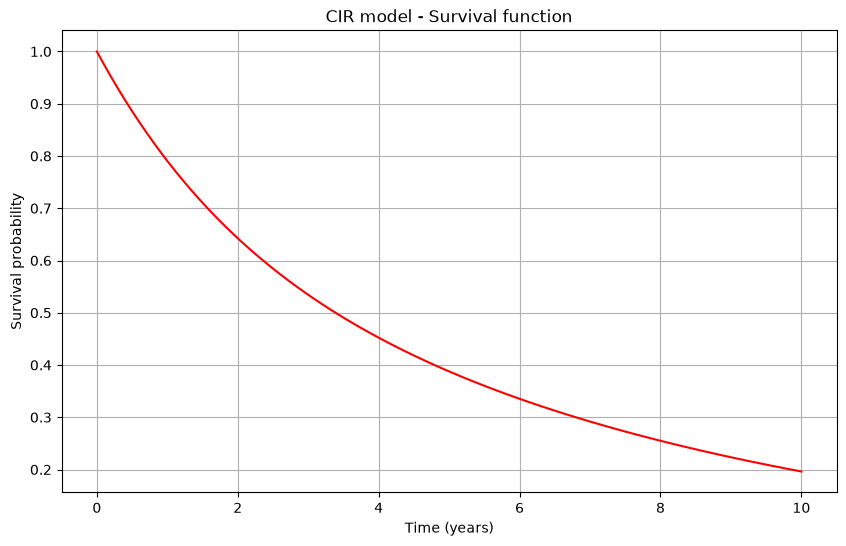

In [242]:
plt.figure(figsize=[10, 6])
plt.plot(T_grid, S, color='r')
plt.xlabel('Time (years)')
plt.ylabel('Survival probability')
plt.title('CIR model - Survival function')
plt.grid(True)
plt.show()

The fair premium of a CDS is given by:

\begin{equation*}
R = \frac{\mathbb{E}_t\left[LGD \cdot D(0,\tau)\, 1_{\{0 < \tau \leq T_b\}}\right]}{\alpha_i\, \mathbb{E}_t\left[\sum_{i=1}^b D(0,T_i)\, 1_{\{\tau > T_i\}}\right]}
\end{equation*}

where $\alpha_i$ is the year fraction between payment dates ($\alpha_i = 1$ for annual payments). The numerator is the protection leg and the denominator is the (risky) annuity of the premium leg.

In [243]:
LGD = 5e6  # Loss Given Default ($)
r = 0.035
k, theta, sigma = 0.3, 0.15, 0.2
lambda0 = 0.25
T_CDS = 5
payment_times = np.arange(1, T_CDS + 1)  # annual premium payments at T = 1, ..., 5

In [244]:
# Survival probabilities at payment time
S_payments = CIR_intensity_process(k, theta, sigma, lambda0, t, payment_times)

In [245]:
# Protection leg
t_grid = np.linspace(0, T_CDS, 10000)  # Griglia fine per l'integrazione
S_grid = CIR_intensity_process(k, theta, sigma, lambda0, t, t_grid)
protection_leg = LGD * np.sum(np.exp(-r * t_grid[1:]) * (S_grid[:-1] - S_grid[1:]))

# Premium Leg
discount_factors = np.exp(-r * payment_times)
premium_leg = np.sum(discount_factors * S_payments)

In [246]:
# Fair premium: protection leg / premium leg
fair_premium = protection_leg / premium_leg  # $ per year

print(f"Fair CDS premium: {fair_premium:,.0f} $ per year "
      f"({fair_premium / LGD * 1e4:,.0f} bps of the ${LGD/1e6:.0f} mln protected amount)")

Fair CDS premium: 1,119,672 $ per year (2,239 bps of the $5 mln protected amount)


The CDS premium should increase with the initial default intensity $\lambda_0$: the higher the current credit risk, the more expensive the protection. We check it by re-pricing the contract for different values of $\lambda_0$.

In [247]:
def cds_premium(lambda0):
    S_pay = CIR_intensity_process(k, theta, sigma, lambda0, 0, payment_times)
    S_fine = CIR_intensity_process(k, theta, sigma, lambda0, 0, t_grid)
    protection = LGD * np.sum(np.exp(-r * t_grid[1:]) * (S_fine[:-1] - S_fine[1:]))
    annuity = np.sum(np.exp(-r * payment_times) * S_pay)
    return protection / annuity

lambda0_grid = [0.05, 0.10, 0.15, 0.25, 0.35, 0.50]
premiums = np.array([cds_premium(l0) for l0 in lambda0_grid])

pd.DataFrame({'Annual premium ($)': premiums.round(0),
              'Premium (bps of protected amount)': (premiums / LGD * 1e4).round(0)},
             index=pd.Index(lambda0_grid, name='lambda_0'))

,Annual premium ($),Premium (bps of protected amount)
lambda_0,,
0.05,480327.0,961.0
0.10,626671.0,1253.0
0.15,781650.0,1563.0
0.25,1119672.0,2239.0
0.35,1498960.0,2998.0
0.50,2156243.0,4312.0


## Hazard-rate estimation from default frequencies

Consider the default frequencies reported in Example 37 (Roncalli). Estimate the hazard function under the exponential, the Gompertz and the piecewise exponential assumptions and plot them, together with their associated survival functions.

To estimate the parameters of the survival function we use the cohort approach:
- we first compute the empirical survival function $\hat S(t)$ from the cumulative default frequencies

\begin{equation*}
\hat S (t) = 1 - \frac{\sum^n_{i=1} 1_{\{\tau_i \leq t\}}}{n}
\end{equation*}

- then we fit the parametric survival function by least squares

We firstly fit the exponential distribution:

$$
S(t) = exp(-\lambda t)
$$

In [248]:
# Cohort data (Roncalli, Example 37): observation times and cumulative number of defaults among n firms
dt = np.array([3, 6, 9, 12, 15, 18, 21, 22])
nd = np.array([2, 5, 9, 12, 16, 20, 25, 29])
n = 1000  # firms

In [249]:
S_est = 1 - (nd / n)

In [250]:
def S_exponential(lam, t):
    return np.exp(-lam * t)

In [251]:
def loss_exponential(params):
    return np.sum((S_exponential(params[0], dt) - S_est) ** 2)

In [252]:
result = minimize(loss_exponential, x0=[0.01], bounds=[(0, None)])
lam_exp = result.x[0]
print(f"Exponential model: lambda = {lam_exp:.5f}")

Exponential model: lambda = 0.00117


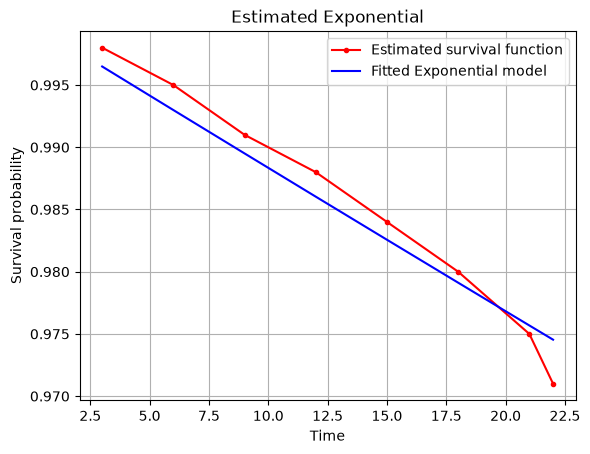

In [253]:
plt.plot(dt, S_est, color='red', label='Estimated survival function', marker='.')
plt.plot(dt, S_exponential(lam_exp, dt), color='b', label='Fitted Exponential model')
plt.xlabel('Time')
plt.ylabel('Survival probability')
plt.grid()
plt.legend()
plt.title("Estimated Exponential")
plt.show()

Now we fit the Gompertz distribution:

$$
S(t) = \exp\left(\lambda(1-e^{\gamma t})\right), \qquad \lambda(t) = \lambda\gamma e^{\gamma t}
$$

In [254]:
def S_gompertz(params, t):
    gamma, lam = params
    return np.exp(lam * (1 - np.exp(gamma * t)))

def loss_gompertz(params):
    return np.sum((S_gompertz(params, dt) - S_est) ** 2)

# Minimization
result = minimize(loss_gompertz, x0=[0.01, 0.01], bounds=[(0, None), (0, None)])
gamma_hat, lam_gomp = result.x
print(f"Gompertz model: lambda = {lam_gomp:.5f}, gamma = {gamma_hat:.5f}")

Gompertz model: lambda = 0.01618, gamma = 0.04597


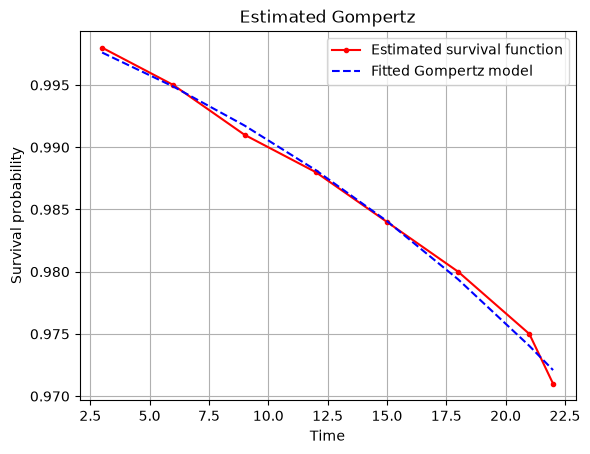

In [255]:
plt.plot(dt, S_est, color='red', label='Estimated survival function', marker='.')
plt.plot(dt, S_gompertz([gamma_hat, lam_gomp], dt), color='blue', linestyle='--', label='Fitted Gompertz model')
plt.xlabel('Time')
plt.ylabel('Survival probability')
plt.grid()
plt.legend()
plt.title("Estimated Gompertz")
plt.show()

## Hazard rates from a credit migration matrix

Consider the credit migration matrix in Table 3.34. Estimate the piecewise constant hazard function λi(t) with yearly knots for all the rating classes and t up to 150, reproducing figure 3.35 in Roncalli’s book.

In [256]:
ratings = ["AAA", "AA" , "A" , "BBB" , "BB", "B", "CCC", "D"]

In [257]:
# Each dictionary entry is a column, i.e. the probability of migrating *to* that rating
# (rows = rating at time 0, columns = rating after one year)
credit_migration_matrix = pd.DataFrame({
    'AAA': [92.82, 0.63, 0.08, 0.05, 0.04, 0.00, 0.19, 0.00],
    'AA': [6.50, 91.67, 2.26, 0.27, 0.11, 0.11, 0.00, 0.00],
    'A': [0.00, 6.64, 91.66, 5.84, 0.64, 0.30, 0.38, 0.00],
    'BBB': [0.56, 0.65, 5.11, 87.74, 7.85, 0.42, 0.75, 0.00],
    'BB': [0.06, 0.06, 0.61, 4.74, 81.14, 6.75, 2.44, 0.00],
    'B': [0.00, 0.11, 0.23, 0.98, 8.27, 83.07, 12.03, 0.00],
    'CCC': [0.00, 0.04, 0.01, 0.16, 0.89, 3.86, 60.71, 0.00],
    'D': [0.00, 0.00, 0.04, 0.22, 1.06, 5.49, 23.50, 100.00]
}, index=ratings)

credit_migration_matrix = credit_migration_matrix / 100

credit_migration_matrix  # check that it corresponds to Roncalli, Table 3.34

,AAA,AA,A,BBB,BB,B,CCC,D
AAA,0.9282,0.0650,0.0000,0.0056,0.0006,0.0000,0.0000,0.0000
AA,0.0063,0.9167,0.0664,0.0065,0.0006,0.0011,0.0004,0.0000
A,0.0008,0.0226,0.9166,0.0511,0.0061,0.0023,0.0001,0.0004
BBB,0.0005,0.0027,0.0584,0.8774,0.0474,0.0098,0.0016,0.0022
BB,0.0004,0.0011,0.0064,0.0785,0.8114,0.0827,0.0089,0.0106
B,0.0000,0.0011,0.0030,0.0042,0.0675,0.8307,0.0386,0.0549
CCC,0.0019,0.0000,0.0038,0.0075,0.0244,0.1203,0.6071,0.2350
D,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000


In [258]:
# Because of rounding in the published table, the AAA and AA rows sum to slightly less than 1.
print(credit_migration_matrix.sum(axis=1).round(4).to_string())

# Rows are renormalised so that P is a proper stochastic matrix
P = credit_migration_matrix.values
P = P / P.sum(axis=1, keepdims=True)

AAA    0.9994
AA     0.9980
A      1.0000
BBB    1.0000
BB     1.0000
B      1.0000
CCC    1.0000
D      1.0000


The survival probability at time $t$ of a firm initially in state $i$ is:

\begin{equation*}
S_i(t) = 1 - \mathbb{P}[\mathcal{R}(t) = K \mid \mathcal{R}(0)=i] = 1 - e_i' P^{t} e_K
\end{equation*}

where $K$ is the absorbing state corresponding to "D". Numerically, $S_i(t)$ is computed as the probability mass left in the non-default states, which avoids the loss of precision of $1 - (\cdot)$ when the default probability approaches one. The piecewise constant hazard rates with yearly knots are:

\begin{equation*}
\lambda_m = \frac{\ln S(t_{m-1}) - \ln S(t_m)}{t_m - t_{m-1}}
\end{equation*}

In [259]:
n_states = len(ratings)
horizon = 150

# survival[t, i] = S_i(t) for the 7 non-default ratings, t = 0, ..., 150
survival = np.zeros((horizon + 1, n_states - 1))
P_t = np.eye(n_states)
for t in range(horizon + 1):
    survival[t] = P_t[:-1, :-1].sum(axis=1)  # mass left in non-default states, for each non-default starting rating
    P_t = P_t @ P

# Piecewise-constant hazard rates with yearly knots, in bps: hazard[t-1, i] = lambda_i(t), t = 1, ..., 150
hazard = -np.diff(np.log(survival), axis=0) * 1e4

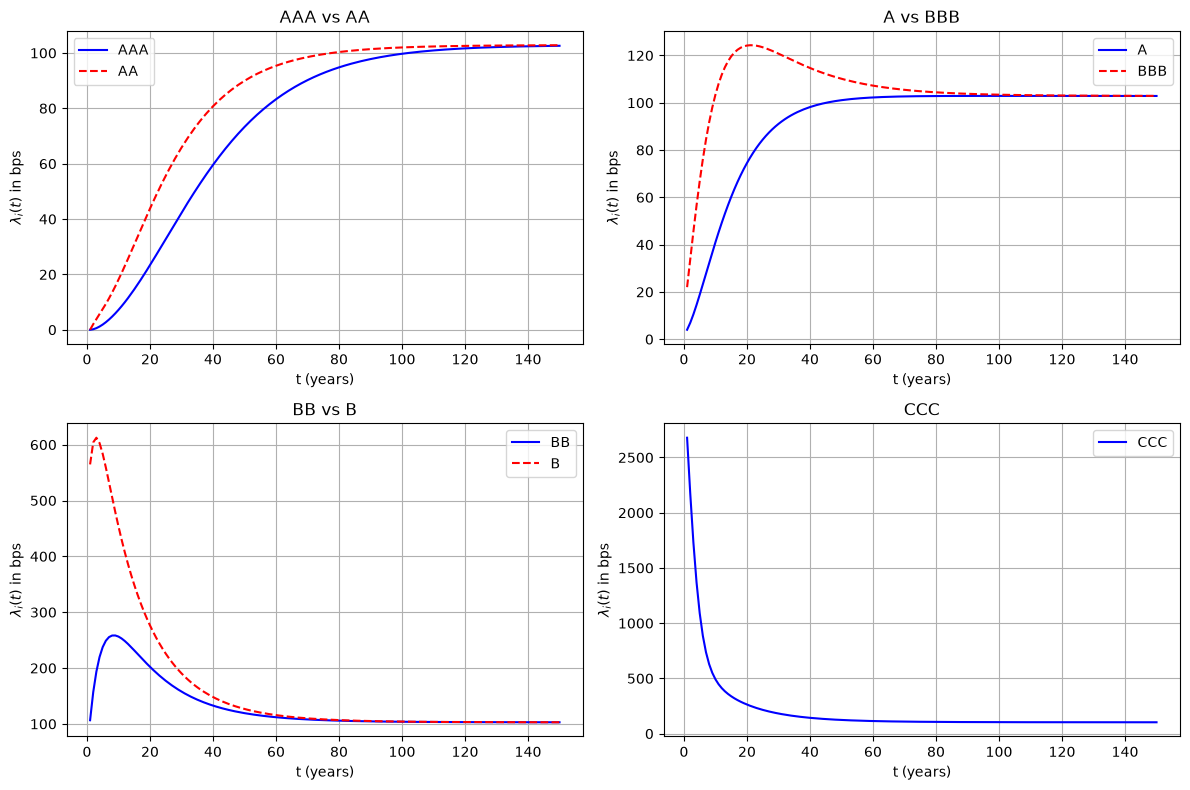

In [260]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
t_range = np.arange(1, horizon + 1)

groups = [['AAA', 'AA'], ['A', 'BBB'], ['BB', 'B'], ['CCC']]
line_colors = ['blue', 'red']
line_styles = ['solid', 'dashed']

for ax, group in zip(axes.ravel(), groups):
    for name, c, ls in zip(group, line_colors, line_styles):
        ax.plot(t_range, hazard[:, ratings.index(name)], label=name, linestyle=ls, color=c)
    ax.set_xlabel('t (years)')
    ax.set_ylabel(r'$\lambda_i(t)$ in bps')
    ax.set_title(' vs '.join(group))
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()

All rating classes converge to the same long-run hazard rate (about 100 bps), the quasi-stationary default intensity of the migration chain. Investment-grade ratings start from a hazard close to zero and increase with horizon as firms migrate towards lower ratings, while speculative-grade ratings (BB, B, CCC) start higher and decrease as the surviving firms are those that did not default.

# **Default Correlation**

Consider the data in Example 36 in Roncalli’s book and the empirical distribution of LGDs. 

Assume a Basel one-factor model and plot the loss distribution, compute its VaR and ES when the Gaussian copula correlation is ρ = 0,0.2,0.5. Use Monte Carlo Simulation with at least 100000 scenarios.

In [261]:
# Data from Roncalli, Example 36 (intensities) and Example 35 (empirical LGD distribution)

T = 5  # maturity
EAD = 1000
LGD = np.array([0, 0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1])
w_lgd = np.array([0.01, 0.02, 0.1, 0.25, 0.1, 0.02, 0, 0.02, 0.1, 0.25, 0.1, 0.02, 0.01])
lam_i = np.array([10, 10, 25, 25, 50, 100, 250, 500, 500, 1000])  # in bps
lam_i_decimal = lam_i / 10000
n_loans = len(lam_i)

# Simulation setup

n_scenarios = 10**5
rho_grid = [0, 0.2, 0.5]

In [262]:
# Individual default probabilities over [0, T] implied by the exponential intensities,
# and the default thresholds of the Basel (Merton) model: default if Z_i <= B_i = Phi^{-1}(PD_i)
pd_i = expon.cdf(T, scale=1 / lam_i_decimal)
B = norm.ppf(pd_i)

# Common random numbers across the three correlation levels, so that the results are comparable
x = rng.standard_normal(n_scenarios)                                   # systematic risk factor
e = rng.standard_normal((n_loans, n_scenarios))                        # idiosyncratic shocks
lgd_draws = rng.choice(LGD, size=(n_loans, n_scenarios), p=w_lgd)      # LGD of each loan in each scenario

losses = np.zeros((len(rho_grid), n_scenarios))
for j, r_ in enumerate(rho_grid):
    Z = np.sqrt(r_) * x + np.sqrt(1 - r_) * e       # latent variables of the Gaussian one-factor copula
    default = Z <= B[:, None]
    losses[j] = (EAD * lgd_draws * default).sum(axis=0)

In [263]:
VaR = np.percentile(losses, 99, axis=1)

for r_, v, el in zip(rho_grid, VaR, losses.mean(axis=1)):
    print(f'rho = {r_}: VaR 99% = {v:,.0f}  (expected loss = {el:,.0f})')

rho = 0: VaR 99% = 2,050  (expected loss = 532)
rho = 0.2: VaR 99% = 2,450  (expected loss = 532)
rho = 0.5: VaR 99% = 3,050  (expected loss = 532)


In [264]:
Es = np.array([l[l >= v].mean() for l, v in zip(losses, VaR)])

for r_, es in zip(rho_grid, Es):
    print(f'rho = {r_}: ES 99% = {es:,.0f}')

rho = 0: ES 99% = 2,342
rho = 0.2: ES 99% = 2,795
rho = 0.5: ES 99% = 3,543


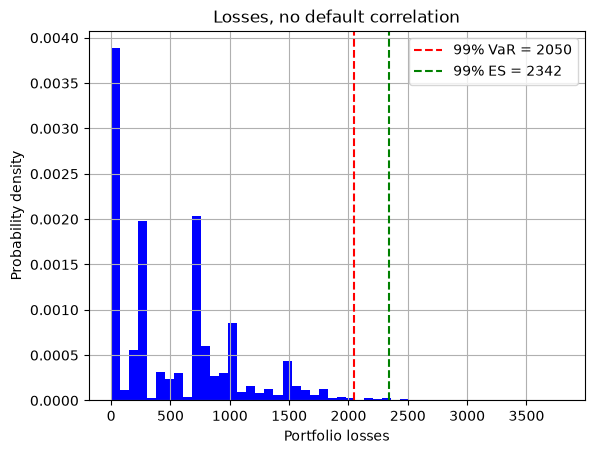

In [265]:
#Plot for rho = 0 (no correlation)

plt.hist(losses[0], bins=50, color='blue', density= True)
plt.xlabel('Portfolio losses')  
plt.ylabel('Probability density')
plt.title('Losses, no default correlation')
plt.axvline(VaR[0], color='red', linestyle='--', label=f'99% VaR = {VaR[0]:.0f}')
plt.axvline(Es[0], color='green', linestyle='--', label=f'99% ES = {Es[0]:.0f}')
plt.grid()
plt.legend()
plt.show()

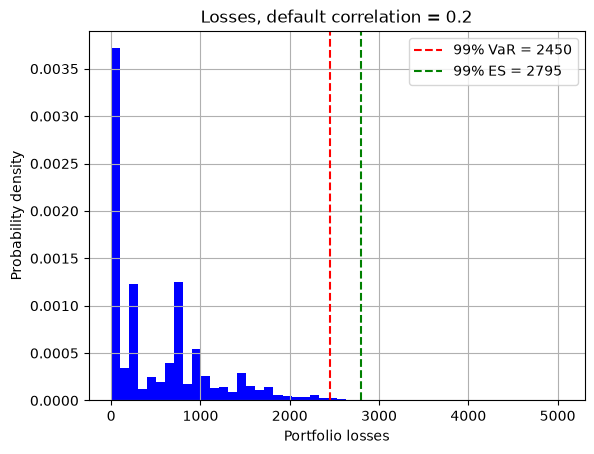

In [266]:
# Plot for rho = 0.2

plt.hist(losses[1], bins=50, color='blue', density= True)
plt.xlabel('Portfolio losses')  
plt.ylabel('Probability density')
plt.title('Losses, default correlation = 0.2')
plt.axvline(VaR[1], color='red', linestyle='--', label=f'99% VaR = {VaR[1]:.0f}')
plt.axvline(Es[1], color='green', linestyle='--', label=f'99% ES = {Es[1]:.0f}')
plt.legend()
plt.grid()
plt.show()

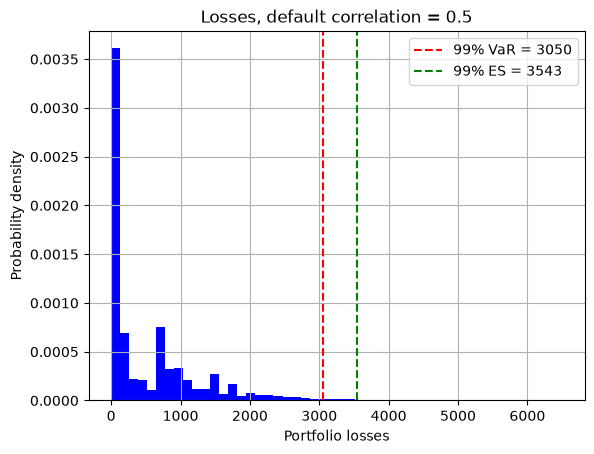

In [267]:
# Plot for rho = 0.5

plt.hist(losses[2], bins=50, color='blue', density= True)
plt.xlabel('Portfolio losses')  
plt.ylabel('Probability density')
plt.title('Losses, default correlation = 0.5')
plt.axvline(VaR[2], color='red', linestyle='--', label=f'99% VaR = {VaR[2]:.0f}')
plt.axvline(Es[2], color='green', linestyle='--', label=f'99% ES = {Es[2]:.0f}')
plt.legend()
plt.grid()
plt.show()

As $\rho$ increases, both VaR and ES increase while the expected loss stays the same: default correlation does not change the average loss but fattens the right tail of the distribution, because defaults tend to cluster.

# **Counterparty credit risk**

 Consider a bank which has bought at time 0 100 ATM call options of an asset initially valued 100 with one-year maturity. The asset evolves as a geometric brownian motion with r = 5% and σ = 20% under the risk neutral measure. At time t0 = 0.5 the asset price is 114.77$. 

Using 10000 simulated scenarios estimate the pdf of MtM(1) and of the exposure at time 1, e(1). Calculate, from the point of view of time t0, the expected exposure and the potential future exposure at probability level 1% and 5%. Compute the CVA of the contract at time 0, if the default probability of the counterparty is 0.02% over the 1-year horizon and the expected LGD is 50%.

In [268]:
# Contract and market data

T = 1  # one year maturity
t0 = 0.5
r = 0.05
sigma = 0.2
S_t0 = 114.77  # price at t0
n_scenarios = 10**4
K = 100
n_options = 100

Under the risk-neutral measure the asset price at time $T$, simulated from $t_0$, is:

\begin{equation*}
S_T = S_{t_0} \exp\left(\left(r - \frac{\sigma^2}{2}\right)(T - t_0) + \sigma \sqrt{T - t_0}\, Z\right), \qquad Z \sim \mathcal{N}(0,1)
\end{equation*}

In [269]:
# Black-Scholes price at time 0 (used for the CVA check below)
_, _, C0 = BS_pricing(option_type="call", t=0, T=T, K=K, r=r, sigma=sigma, S0=100)

rng_ccr = np.random.default_rng(3)  # seeded for reproducibility
Z = rng_ccr.standard_normal(n_scenarios)

# Simulate the price of the asset at T = 1, starting from S(t0) = 114.77
S1 = S_t0 * np.exp((r - 0.5 * sigma**2) * (T - t0) + sigma * np.sqrt(T - t0) * Z)

For a long call position, the value of the contract at maturity is $\text{MtM}(1) = n\,\max(S_1 - K, 0)$. The premium paid at time 0 is a sunk cost and does not enter the exposure. Since $\text{MtM}(1) \geq 0$, the exposure $e(1) = \max(\text{MtM}(1), 0)$ coincides with the MtM, and its distribution has a point mass at zero (scenarios in which the option expires out of the money).

In [270]:
payoff = np.maximum(S1 - K, 0)
mtm = n_options * (payoff - C0)            # MtM at T = 1
exposure = np.maximum(mtm, 0)       # positive part: what is lost if the counterparty defaults

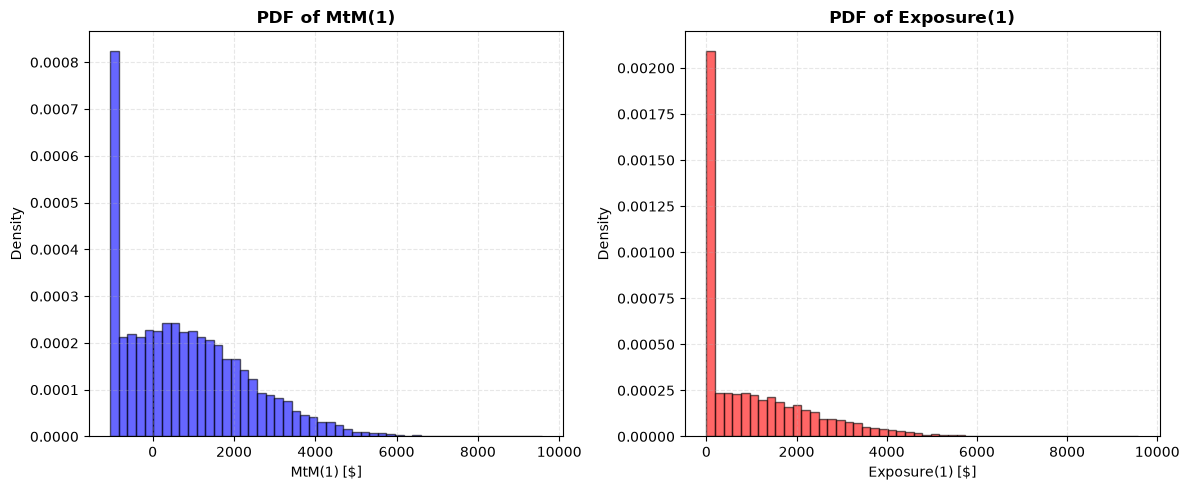

In [271]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(mtm, bins=50, density=True, alpha=0.6, color='b', edgecolor='k')
plt.title('PDF of MtM(1)', fontweight='bold')
plt.xlabel('MtM(1) [$]')
plt.ylabel('Density')
plt.grid(linestyle='--', alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(exposure, bins=50, density=True, alpha=0.6, color='r', edgecolor='k')
plt.title('PDF of Exposure(1)', fontweight='bold')
plt.xlabel('Exposure(1) [$]')
plt.ylabel('Density')
plt.grid(linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [272]:
expected_exposure = np.mean(exposure)
pfe_99 = np.percentile(exposure, 99)
pfe_95 = np.percentile(exposure, 95)

In [273]:
print(f"Expected Exposure: {expected_exposure:.2f}")
print(f"PFE at the 1% level (99th percentile): {pfe_99:.2f}")
print(f"PFE at the 5% level (95th percentile): {pfe_95:.2f}")

Expected Exposure: 1072.87
PFE at the 1% level (99th percentile): 5083.64
PFE at the 5% level (95th percentile): 3659.22


The CVA at time 0 is computed from the exposure profile seen from time 0 (starting from $S(0) = 100$). With independence between exposure and default, a constant recovery, and a default probability $PD$ over the horizon:

\begin{equation*}
\text{CVA} = LGD \cdot PD \cdot D(0,T) \cdot EE(T)
\end{equation*}

Under the risk-neutral measure $D(0,T)\,EE(T) = n \cdot C_0$, so the Monte Carlo estimate can be checked against the closed form $LGD \cdot PD \cdot n \cdot C_0$.

In [274]:
default_prob = 0.0002
LGD = 0.5

# Monte Carlo estimate from time 0: exposure at T = 1 starting from S(0) = 100
Z0 = rng_ccr.standard_normal(n_scenarios)
S1_from_0 = 100 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z0)
exposure_0 = n_options * np.maximum(S1_from_0 - K, 0)
cva_mc = LGD * default_prob * np.exp(-r * T) * exposure_0.mean()

# Closed form: discounted expected exposure = price of the option position
cva_closed_form = LGD * default_prob * n_options * C0

premium_paid = n_options * C0
print(f"CVA (Monte Carlo): {cva_mc:.4f} $")
print(f"CVA (closed form): {cva_closed_form:.4f} $  ({cva_closed_form / premium_paid * 1e4:.2f} bps of the premium paid, {premium_paid:,.2f} $)")

CVA (Monte Carlo): 0.1046 $
CVA (closed form): 0.1045 $  (1.00 bps of the premium paid, 1,045.06 $)
